# Correctness Evaluation: Categorization Accuracy and Extraction Correctness

**Research question.** The other notebooks in this directory measure what the pipeline
*does* (fetch outcomes, category distribution, extraction completeness, timing) - none of
them measure whether it is actually *right*. This notebook asks that question directly:
against a hand-labeled ground truth, how accurate is `category_service.categorize_website()`
at distinguishing `STATION`/`LIST`/`IRRELEVANT`, and how correct are
`extraction_service.extract_information()`'s field values against real, human-transcribed
station data?

**Data.** Gold labels are scored against a real crawl session's actual database results
(`crawl_gpu_session.db`, the GPU-based session), not an isolated re-fetch-and-recategorize
run - a real session's fetch timing, Playwright browser lifecycle, and page state at crawl
time are what the pipeline actually saw, which an isolated harness re-running the same URLs
later is not guaranteed to reproduce identically. See
`experiments/compare_categorization_gold_to_crawl_db.py` and
`experiments/compare_gold_to_crawl_db.py`'s module docstrings for why this replaced the
original isolated-experiment approach.

- `experiments/compare_categorization_gold_to_crawl_db.py` -> `categorization_gold_vs_real_crawl.csv`,
  one row per hand-labeled URL in `categorization_gold_labels.csv` (n=58 unique URLs, 56
  found in `crawl_gpu_session.db`, 47 successfully fetched there).
- `experiments/compare_gold_to_crawl_db.py` -> `gold_vs_real_crawl.csv` (one row per gold
  entry, matched to an extracted entry by name similarity) and
  `gold_vs_real_crawl_entry_counts.csv` (gold vs. extracted entry counts per source page),
  against `extraction_gold_labels.csv` (22 gold entries across 4 source URLs).

The original isolated-experiment outputs (`categorization_accuracy.csv`,
`extraction_correctness.csv`) are still used below for exactly one thing: the
per-page categorization *timing* histogram, since a real crawl session's per-page
categorize time lives in that session's own `_page_timing.csv`
(`experiments/analyze_session.py`), not in these gold-comparison CSVs, and mixing two
different timing sources into one histogram would not be meaningful.

**Methodology note.** An earlier version of the categorization-accuracy experiment capped
page content at 4000 characters before categorization, to keep runtime down - a pattern
copied from the unrelated timing experiment (`collect_crawl_metrics.py`), applied without
checking whether it was appropriate for an *accuracy* measurement. It was not: truncating
the page text a model is asked to judge can change the judgment itself, so a capped run is
not evidence about how the production pipeline (which sees full page content) actually
behaves. That run's numbers were discarded; the experiment now runs uncapped by default
(full real page content).

## Setup

In [1]:
import sys
sys.path.insert(0, ".")
from plotting import set_style, savefig, load_csv, PALETTE, wilson_ci, integer_axis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_style()

# Isolated re-fetch experiment - kept only for the categorization *timing*
# histogram below (see intro cell for why).
cat_df = load_csv("categorization_accuracy.csv")
cat_df["fetch_success"] = cat_df["fetch_success"].astype(bool)
cat_df["correct"] = cat_df["correct"].map({"True": True, "False": False, True: True, False: False})

# Real GPU-session crawl results - primary data source for accuracy/confusion matrix below.
gpu_cat_df = load_csv("categorization_gold_vs_real_crawl.csv")
gpu_cat_df["fetch_success"] = gpu_cat_df["fetch_success"].astype(bool)
gpu_cat_df["correct"] = gpu_cat_df["correct"].map({"True": True, "False": False, True: True, False: False})
gpu_cat_df

,url,true_category,predicted_category,correct,fetch_success
0,https://rlp.nabu.de/tiere-und-pflanzen/tieren-...,LIST,LIST,True,True
1,https://www.vbu-ffm.de/pflegestationen.shtml,LIST,LIST,True,True
2,https://deutsche-wildtierrettung.de/wildtierau...,LIST,LIST,True,True
3,https://www.wildtierschutz-deutschland.de/wild...,LIST,LIST,True,True
4,https://www.wildtierschutz-deutschland.de/wild...,LIST,LIST,True,True
5,https://www.wildtierschutz-deutschland.de/wild...,LIST,LIST,True,True
6,https://www.wildtierschutz-deutschland.de/wild...,LIST,LIST,True,True
7,https://www.wildtierschutz-deutschland.de/wild...,LIST,LIST,True,True
8,https://www.wildtierschutz-deutschland.de/wild...,LIST,LIST,True,True
9,https://www.wildtierschutz-deutschland.de/wild...,LIST,LIST,True,True


## Categorization accuracy

Only successfully-fetched pages reach categorization, so accuracy is computed over the
subset with `fetch_success == True`. Fetch failures (Facebook URLs blocking scrapers,
one dead domain, robots.txt-disallowed pages) are excluded rather than counted as wrong,
since they never reached the categorization step at all. Two gold URLs were never crawled
in this GPU session at all (not in `crawl_gpu_session.db`) and are excluded from
`n_total` below entirely, not just from `n_fetched`.

In [2]:
fetched = gpu_cat_df[gpu_cat_df["fetch_success"]].copy()
n_total = len(gpu_cat_df)
n_fetched = len(fetched)
n_correct = int(fetched["correct"].sum())
accuracy = 100 * n_correct / n_fetched

# Isolated experiment's fetched subset, kept only for the timing histogram later.
isolated_fetched = cat_df[cat_df["fetch_success"]].copy()

print(f"{n_total} gold-labeled URLs found in crawl_gpu_session.db, {n_fetched} fetched successfully "
      f"({n_total - n_fetched} fetch failures excluded)")
print(f"Overall accuracy: {n_correct}/{n_fetched} = {accuracy:.1f}%")

56 gold-labeled URLs found in crawl_gpu_session.db, 47 fetched successfully (9 fetch failures excluded)
Overall accuracy: 35/47 = 74.5%


### Confusion matrix

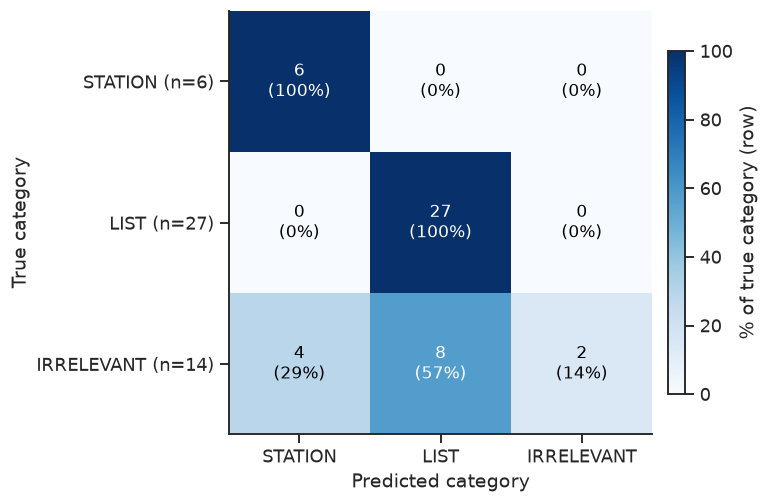

Caption: Categorization confusion matrix over the n=47 successfully fetched, hand-labeled URLs. Cell color encodes the row-normalized percentage (recall for that true category); cell text shows count and percentage.


In [3]:
CATS = ["STATION", "LIST", "IRRELEVANT"]
cm = pd.crosstab(fetched["true_category"], fetched["predicted_category"])
cm = cm.reindex(index=CATS, columns=CATS, fill_value=0)
row_totals = cm.sum(axis=1)
cm_pct = cm.div(row_totals, axis=0) * 100  # row-normalized: recall per true category

fig, ax = plt.subplots(figsize=(6.6, 4.8))
im = ax.imshow(cm_pct.values, cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(len(CATS)))
ax.set_yticks(range(len(CATS)))
ax.set_xticklabels(CATS)
ax.set_yticklabels([f"{c} (n={row_totals[c]})" for c in CATS])
ax.set_xlabel("Predicted category")
ax.set_ylabel("True category")
for i in range(len(CATS)):
    for j in range(len(CATS)):
        count = cm.values[i, j]
        pct = cm_pct.values[i, j]
        color = "white" if pct > 50 else "black"
        ax.text(j, i, f"{count}\n({pct:.0f}%)", ha="center", va="center", color=color, fontsize=11)
fig.colorbar(im, ax=ax, label="% of true category (row)", shrink=0.8, pad=0.03)
fig.tight_layout()
savefig(fig, "categorization_confusion_matrix")
plt.show()
print(f"Caption: Categorization confusion matrix over the n={n_fetched} successfully "
      f"fetched, hand-labeled URLs. Cell color encodes the row-normalized percentage "
      f"(recall for that true category); cell text shows count and percentage.")

### Precision and recall per category

In [4]:
rows = []
for c in CATS:
    tp = cm.loc[c, c]
    true_total = cm.loc[c].sum()
    pred_total = cm[c].sum()
    recall = 100 * tp / true_total if true_total else float("nan")
    precision = 100 * tp / pred_total if pred_total else float("nan")
    recall_ci = wilson_ci(int(tp), int(true_total)) if true_total else (float("nan"), float("nan"))
    precision_ci = wilson_ci(int(tp), int(pred_total)) if pred_total else (float("nan"), float("nan"))
    rows.append({
        "category": c, "true_count": true_total, "predicted_count": pred_total,
        "recall_%": round(recall, 1),
        "recall_95ci": f"[{recall_ci[0]*100:.0f}, {recall_ci[1]*100:.0f}]" if true_total else "n/a",
        "precision_%": round(precision, 1) if pred_total else float("nan"),
        "precision_95ci": f"[{precision_ci[0]*100:.0f}, {precision_ci[1]*100:.0f}]" if pred_total else "n/a (never predicted)",
    })
metrics = pd.DataFrame(rows).set_index("category")
metrics

,true_count,predicted_count,recall_%,recall_95ci,precision_%,precision_95ci
category,,,,,,
STATION,6,10,100.0,"[61, 100]",60.0,"[31, 83]"
LIST,27,35,100.0,"[88, 100]",77.1,"[61, 88]"
IRRELEVANT,14,2,14.3,"[4, 40]",100.0,"[34, 100]"


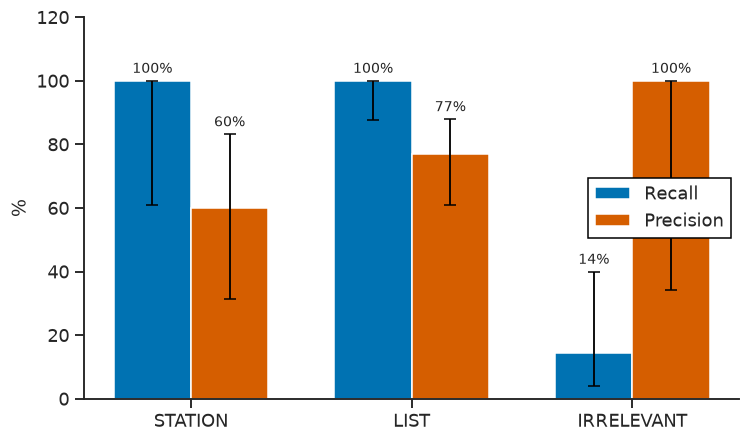

Caption: Recall and precision per category (n=47 fetched URLs). Error bars show the 95% Wilson confidence interval; every category was predicted at least once, so all precision values are defined.


In [5]:
fig, ax = plt.subplots(figsize=(7, 4.2))
x = np.arange(len(CATS))
width = 0.35

recall_vals, recall_err_lo, recall_err_hi = [], [], []
precision_vals, precision_err_lo, precision_err_hi = [], [], []
for c in CATS:
    tp = int(cm.loc[c, c])
    true_total = int(cm.loc[c].sum())
    pred_total = int(cm[c].sum())

    r = 100 * tp / true_total if true_total else 0
    recall_vals.append(r)
    if true_total:
        lo, hi = wilson_ci(tp, true_total)
        recall_err_lo.append(r - lo * 100)
        recall_err_hi.append(hi * 100 - r)
    else:
        recall_err_lo.append(0)
        recall_err_hi.append(0)

    p = 100 * tp / pred_total if pred_total else 0
    precision_vals.append(p)
    if pred_total:
        lo, hi = wilson_ci(tp, pred_total)
        precision_err_lo.append(p - lo * 100)
        precision_err_hi.append(hi * 100 - p)
    else:
        precision_err_lo.append(0)
        precision_err_hi.append(0)

ax.bar(x - width/2, recall_vals, width, label="Recall", color=PALETTE[0],
       yerr=[recall_err_lo, recall_err_hi], capsize=4, ecolor="black", error_kw={"elinewidth": 1.2})
ax.bar(x + width/2, precision_vals, width, label="Precision", color=PALETTE[1],
       yerr=[precision_err_lo, precision_err_hi], capsize=4, ecolor="black", error_kw={"elinewidth": 1.2})

for i, v in enumerate(recall_vals):
    ax.text(i - width/2, v + recall_err_hi[i] + 1.5, f"{v:.0f}%", ha="center", va="bottom", fontsize=9)
for i, v in enumerate(precision_vals):
    pred_total = int(cm[CATS[i]].sum())
    label = "n/a" if pred_total == 0 else f"{v:.0f}%"
    ax.text(i + width/2, v + precision_err_hi[i] + 1.5, label, ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(CATS)
ax.set_ylabel("%")
ax.set_ylim(0, 120)
ax.legend()
fig.tight_layout()
savefig(fig, "categorization_precision_recall")
plt.show()

undefined_cats = [c for c in CATS if int(cm[c].sum()) == 0]
undefined_note = (f"; {', '.join(undefined_cats)} precision is undefined (never predicted), shown as n/a"
                   if undefined_cats else "; every category was predicted at least once, so all precision values are defined")
print(f"Caption: Recall and precision per category (n={n_fetched} fetched URLs). Error "
      f"bars show the 95% Wilson confidence interval{undefined_note}.")

Against the real GPU crawl session, `IRRELEVANT` was predicted twice - both times
correctly (2/2, 100% precision) - a real change from the earlier isolated experiment,
which never predicted `IRRELEVANT` at all. Recall for `IRRELEVANT` is still low (2/14,
14.3%): most truly-irrelevant pages are still pulled into `STATION` or `LIST`, so the
class-imbalance bias described in the Discussion section below is reduced, not resolved,
under real crawl conditions. `STATION` and `LIST` both reach 100% recall in this dataset,
at the cost of weaker precision (`STATION` 60%, `LIST` 77.1%) from exactly that same
`IRRELEVANT`-leakage.

### Categorization time

From the isolated single-page experiment, not the GPU session above (see intro cell) -
a real session's own per-page timing is in that session's `_page_timing.csv` via
`experiments/analyze_session.py`, not in the gold-comparison data used for the confusion
matrix.

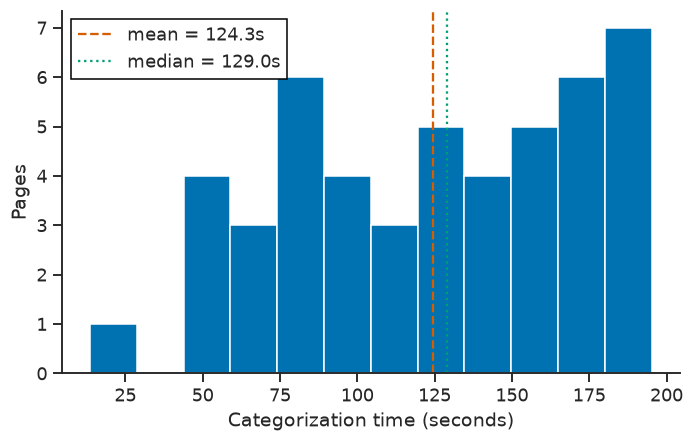

Caption: Distribution of per-page categorization time on full, uncapped page content, isolated single-page experiment (n=48 pages; mean=124.3s, median=129.0s, range 13.5-195.2s).


In [6]:
times = isolated_fetched["categorize_seconds"].astype(float)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.hist(times, bins=12, color=PALETTE[0], edgecolor="white")
ax.axvline(times.mean(), color=PALETTE[1], linestyle="--", label=f"mean = {times.mean():.1f}s")
ax.axvline(times.median(), color=PALETTE[2], linestyle=":", label=f"median = {times.median():.1f}s")
ax.set_xlabel("Categorization time (seconds)")
ax.set_ylabel("Pages")
integer_axis(ax)
ax.legend()
fig.tight_layout()
savefig(fig, "categorization_time_distribution")
plt.show()
print(f"Caption: Distribution of per-page categorization time on full, uncapped page "
      f"content, isolated single-page experiment (n={len(isolated_fetched)} pages; "
      f"mean={times.mean():.1f}s, median={times.median():.1f}s, "
      f"range {times.min():.1f}-{times.max():.1f}s).")

## Extraction correctness

Scored against `crawl_gpu_session.db`'s real extraction results for the gold-labeled
source pages (`experiments/compare_gold_to_crawl_db.py`), not an isolated re-fetch - same
rationale as the categorization section above.

In [7]:
ext_df = load_csv("gold_vs_real_crawl.csv")
counts_df = load_csv("gold_vs_real_crawl_entry_counts.csv")
counts_df

,source_url,category,fetch_success,gold_entry_count,extracted_entry_count
0,https://marswildliferescue.com/,STATION,True,1,1
1,https://wp.wildvogelhilfe.org/auffangstationen...,LIST,True,9,9
2,http://www.greifvogelhilfe.de//greifvogelhilfe,STATION,True,1,1
3,https://rlp.nabu.de/tiere-und-pflanzen/tieren-...,LIST,True,11,11


### Entry counts: gold vs. extracted

For each source page, how many station entries did a human find in the gold-labeling
pass, versus how many entries did the pipeline actually extract? For `STATION` pages this
should be 1-to-1; for the `LIST` page it tests whether the model enumerates every station
on the page or collapses them.

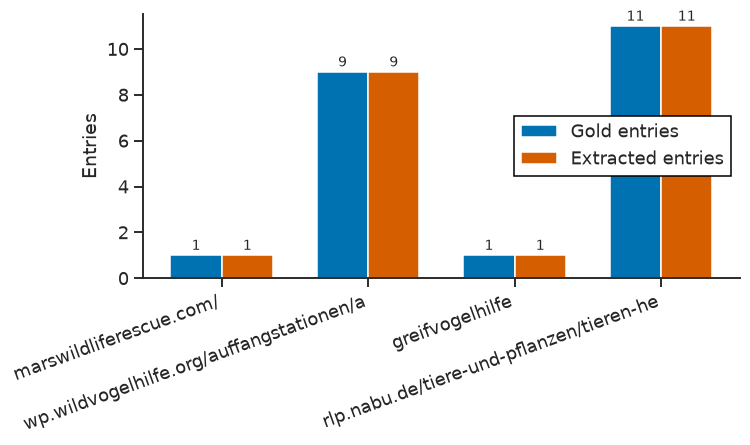

Caption: Gold-labeled vs. extracted entry count per source page (n=4 hand-labeled pages).


In [8]:
fig, ax = plt.subplots(figsize=(7, 4.2))
labels = [u.split("//")[-1][:40] for u in counts_df["source_url"]]
x = np.arange(len(counts_df))
width = 0.35
ax.bar(x - width/2, counts_df["gold_entry_count"], width, label="Gold entries", color=PALETTE[0])
ax.bar(x + width/2, counts_df["extracted_entry_count"], width, label="Extracted entries", color=PALETTE[1])
for i, (g, e) in enumerate(zip(counts_df["gold_entry_count"], counts_df["extracted_entry_count"])):
    ax.text(i - width/2, g + 0.1, str(g), ha="center", va="bottom", fontsize=9)
    ax.text(i + width/2, e + 0.1, str(e), ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Entries")
integer_axis(ax)
ax.legend()
fig.tight_layout()
savefig(fig, "extraction_entry_counts")
plt.show()
print(f"Caption: Gold-labeled vs. extracted entry count per source page (n={len(counts_df)} hand-labeled pages).")

Against the real GPU crawl session, entry counts match gold exactly on all four
source pages, including both `LIST` pages: `wp.wildvogelhilfe.org` (9 gold entries, 9
extracted) and `rlp.nabu.de` (11 gold entries, 11 extracted). This directly contradicts
the earlier isolated experiment's result for `wp.wildvogelhilfe.org` (1 extracted entry
from 9 gold, reproduced identically across independent isolated runs) - see
`experiments/compare_gold_to_crawl_db.py`'s module docstring for the same divergence
observed earlier for a different real session (`session_20260822_022754`). The severe
LIST-page under-extraction reported from the isolated experiment does not appear to hold
for what the pipeline actually does in a real crawl session.

### Field-level match quality (detailed, per gold entry)

This is the full per-entry detail behind the accuracy overview below - moved to the
thesis Appendix rather than the main Results text, since 22 rows is too dense to read as
a primary result.

In [9]:
matched = ext_df[ext_df["name_similarity"] >= 0.3].copy()
print(f"{len(matched)}/{len(ext_df)} gold entries matched to an extracted entry "
      f"(name similarity >= 0.3 threshold)")
matched[["source_url", "gold_name", "extracted_name", "name_similarity",
         "address_similarity", "telephone_match", "accepted_animals_jaccard",
         "animal_pickup_match"]]

22/22 gold entries matched to an extracted entry (name similarity >= 0.3 threshold)


,source_url,gold_name,extracted_name,name_similarity,address_similarity,telephone_match,accepted_animals_jaccard,animal_pickup_match
0,https://marswildliferescue.com/,MARS,MARS Wildlife Rescue,0.333,0.809,True,NaN,True
1,https://wp.wildvogelhilfe.org/auffangstationen...,Greifvogelhilfe Sachsen e. V.,Greifvogelhilfe Sachsen e. V.,1.000,1.000,True,0.00,NaN
2,https://wp.wildvogelhilfe.org/auffangstationen...,NABU Wildvogelhilfe Jena,NABU Wildvogelhilfe Jena,1.000,1.000,NaN,0.00,NaN
3,https://wp.wildvogelhilfe.org/auffangstationen...,Naturschutz-Tierpark Görlitz,Naturschutz-Tierpark Görlitz,1.000,1.000,True,0.00,NaN
4,https://wp.wildvogelhilfe.org/auffangstationen...,Naturschutzstation Neschwitz,Naturschutzstation Neschwitz,1.000,1.000,True,0.00,NaN
5,https://wp.wildvogelhilfe.org/auffangstationen...,Private Vogel- und Igelpflegestation Bad Elster,Private Vogel- und Igelpflegestation Bad Elster,1.000,0.780,True,1.00,NaN
6,https://wp.wildvogelhilfe.org/auffangstationen...,Tierpark Weißwasser e. V.,Tierpark Weißwasser e. V.,1.000,1.000,True,0.00,NaN
7,https://wp.wildvogelhilfe.org/auffangstationen...,Wildvogelhilfe Dölzschen – Rettungsstation für...,Wildvogelhilfe Dölzschen – Rettungsstation für...,1.000,0.805,True,0.25,NaN
8,https://wp.wildvogelhilfe.org/auffangstationen...,Wildvogelhilfe Leipzig,Wildvogelhilfe Leipzig,1.000,1.000,True,1.00,NaN
9,https://wp.wildvogelhilfe.org/auffangstationen...,Falknerei Burg Greifenstein,Falknerei Burg Greifenstein,1.000,1.000,NaN,1.00,NaN


### Accuracy overview, by category

The detailed table above is hard to read as a summary. This aggregates it: for each
field, the share of gold entries where the extracted value was judged correct (`_close`/
`_match` flags, or mean Jaccard overlap for `accepted_animals`), computed only over gold
entries where that field was actually comparable (a blank gold value is excluded, not
counted as wrong - see `gold_scoring.score_entry()`). "Matched" is the share of gold
entries that had *any* corresponding extracted entry at all (name similarity >= 0.3) -
the entry-level counterpart to the entry-count comparison above.

`animal_pickup` is excluded from this overview (and from the thesis tables): almost every
gold row left it blank (comparable for only 1 of 22 entries), so a per-category rate for
it carries essentially no informational value at this sample size - see `ext_df` above for
the raw per-entry values if needed.

In [10]:
def _rate(sub, col):
    """% of non-blank values in col that are truthy, over the non-blank subset. Returns (pct, n)."""
    s = sub[col].replace("", np.nan).dropna()
    if len(s) == 0:
        return None, 0
    s = s.map({"True": True, "False": False, True: True, False: False}) if s.dtype == object else s
    return round(100 * s.mean(), 1), len(s)


def _jaccard_mean(sub):
    s = pd.to_numeric(sub["accepted_animals_jaccard"], errors="coerce").dropna()
    if len(s) == 0:
        return None, 0
    return round(100 * s.mean(), 1), len(s)


overview_rows = []
for label, sub in [("All", ext_df), ("LIST", ext_df[ext_df["category"] == "LIST"]),
                    ("STATION", ext_df[ext_df["category"] == "STATION"])]:
    matched_mask = sub["extracted_name"].notna() & (sub["extracted_name"] != "")
    matched_pct = round(100 * matched_mask.mean(), 1) if len(sub) else None
    name_pct, name_n = _rate(sub, "name_close")
    addr_pct, addr_n = _rate(sub, "address_close")
    tel_pct, tel_n = _rate(sub, "telephone_match")
    animals_pct, animals_n = _jaccard_mean(sub)
    overview_rows.append({
        "split": label, "n_gold": len(sub), "matched_%": matched_pct,
        "name_%": name_pct, "name_n": name_n,
        "address_%": addr_pct, "address_n": addr_n,
        "telephone_%": tel_pct, "telephone_n": tel_n,
        "accepted_animals_jaccard_%": animals_pct, "accepted_animals_n": animals_n,
    })
overview_df = pd.DataFrame(overview_rows).set_index("split")
overview_df.to_csv("../experiments/data/extraction_accuracy_overview.csv")
overview_df

,n_gold,matched_%,name_%,name_n,address_%,address_n,telephone_%,telephone_n,accepted_animals_jaccard_%,accepted_animals_n
split,,,,,,,,,,
All,22,100.0,90.9,22,95.0,20,100.0,20,69.7,19
LIST,20,100.0,95.0,20,94.7,19,100.0,18,68.1,18
STATION,2,100.0,50.0,2,100.0,1,100.0,2,100.0,1


## Discussion

**Categorization.** Scored against the real GPU crawl session, overall accuracy is
74.5% (35/47 fetched pages), and the picture is less one-sided than the earlier isolated
experiment suggested. `STATION` and `LIST` both reach 100% recall but middling precision
(60% and 77.1%), because `IRRELEVANT` pages still frequently leak into them. `IRRELEVANT`
itself is the real weak point: recall is only 14.3% (2/14) - most truly-irrelevant pages
are still misclassified as `STATION`/`LIST` - but it is no longer *never* predicted: the
two times the model did predict `IRRELEVANT`, both were correct (100% precision, 2/2).
That is a genuine, real-crawl-conditions improvement over the isolated experiment's 0%
recall / undefined precision, though the underlying bias (favoring `STATION`/`LIST` over
`IRRELEVANT`) is still the dominant error mode, not a solved problem. Practically, this
still means a meaningful fraction of pages the pipeline would hand to Wildtanic as new
candidate records are not real stations, with the same downstream manual-cleanup cost
discussed before.

**Extraction.** Scored against the same GPU session, entry counts now match gold exactly
on all four gold-labeled pages - including both `LIST` pages (`wp.wildvogelhilfe.org`: 9/9,
`rlp.nabu.de`: 11/11) - directly overturning the earlier isolated experiment's finding that
a 9-station `LIST` page collapsed into one mis-titled entry. Field-level accuracy (accuracy
overview table above) is strong across the board: 90.9% of all 22 gold entries had a
name judged a close match, 95.0% an address match, 100% a telephone match (digit
comparison), and a 69.7% mean Jaccard overlap on `accepted_animals` - the weakest field,
consistent with it being unconstrained free text (see Extraction Design's note on this)
where the model and a human labeler don't always pick the same words for the same
concept (e.g. "Vögel" vs. "Alle Vögel"). The `STATION` split (n=2) is too small to read
much into on its own beyond "not obviously worse than LIST." `animal_pickup` is excluded
from the overview entirely (see the accuracy-overview markdown cell above) - almost every
gold row left it blank, so any per-category rate for it would not be meaningful evidence
either way. Taken together, this is a substantially more positive result than the isolated
pilot reported, and specifically undercuts the isolated experiment's most
attention-grabbing finding (LIST-page collapse) - a caution that isolated single-page
re-fetch experiments are not a reliable substitute for scoring what the pipeline actually
did in a real session, at least for extraction completeness.